In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from scipy.stats import linregress

In [22]:
df = pd.read_csv("run_results_small_model.csv")

In [23]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time,rng_seed
count,12736.000000,12736.0,12736.0,12736.000000,12736.000000,12736.0,1.273600e+04,1.273600e+04,1.273600e+04,1.273600e+04,...,1.273600e+04,12736.000000,1.273600e+04,1.273600e+04,12736.000000,1.273600e+04,12736.000000,12736.000000,12736.000000,12736.000000
mean,1020.015075,2.0,32.0,31.875471,4080.060302,32128.0,3.277104e+07,3.277104e+07,3.277104e+07,2.795585e+06,...,4.636325e-04,0.059609,4.636325e-04,1.159081e-04,0.059609,4.636325e-04,6.265439,6.265439,88.468943,11.331815
std,1324.874346,0.0,0.0,41.402323,5299.497383,0.0,4.256556e+07,4.256556e+07,4.256556e+07,5.449573e+06,...,7.374266e-04,0.033532,7.374266e-04,1.843566e-04,0.033532,7.374266e-04,0.648547,0.648547,136.722945,16.965944
min,32.000000,2.0,32.0,1.000000,128.000000,32128.0,1.028096e+06,1.028096e+06,1.028096e+06,1.024000e+03,...,2.384186e-07,0.000977,2.384186e-07,5.960464e-08,0.000977,2.384186e-07,5.316690,5.316690,11.795817,0.000000
25%,64.000000,2.0,32.0,2.000000,256.000000,32128.0,2.056192e+06,2.056192e+06,2.056192e+06,4.096000e+03,...,3.282747e-05,0.033615,3.282747e-05,8.206868e-06,0.033615,3.282747e-05,5.653930,5.653930,19.177312,1.000000
50%,256.000000,2.0,32.0,8.000000,1024.000000,32128.0,8.224768e+06,8.224768e+06,8.224768e+06,6.553600e+04,...,1.318432e-04,0.052079,1.318432e-04,3.296081e-05,0.052079,1.318432e-04,6.027973,6.027973,33.269682,3.000000
75%,2048.000000,2.0,32.0,64.000000,8192.000000,32128.0,6.579814e+07,6.579814e+07,6.579814e+07,4.194304e+06,...,5.649952e-04,0.080684,5.649952e-04,1.412488e-04,0.080684,5.649952e-04,6.875168,6.875168,88.993121,4.000000
max,4096.000000,2.0,32.0,128.000000,16384.000000,32128.0,1.315963e+08,1.315963e+08,1.315963e+08,1.677722e+07,...,7.812500e-03,0.250000,7.812500e-03,1.953125e-03,0.250000,7.812500e-03,10.534909,10.534909,625.808342,42.000000


In [24]:
print(df['base_lr'].min())
print(df['base_lr'].max())

0.0009765625
0.25


In [25]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_step', 'n_warmup_step',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time',
       'lr_schedule_mode', 'rng_seed'],
      dtype='object')


In [26]:
df = df[df['head_dimension'] == 32]

In [27]:
print(df['n_pretrain_step'].unique())
print(df['n_training_tokens'].unique())
print(df['n_parameters'].unique())
print(df['lr_schedule_mode'].unique())

[ 100 1000]
[ 1638400 16384000]
[  2074688   4186240   8519936  17629696  37618688  84674560 207097856
 565190656]
['relative']


In [28]:
df = df[df['n_pretrain_step'] == 1000]

In [29]:
# calculate effective learning rate (base_lr * sqrt(n_training_tokens))
df['effective_lr'] = df['base_lr'] * np.sqrt(df['n_training_tokens'])

In [30]:
# create column that states whether model was trained to full length or not
df['full_length_training'] = df['n_training_tokens'] == 5.84630272e+09

df_one_seed = df[df["rng_seed"] == 42]

# split into relative and not relative df
df_relative = df[df['lr_schedule_mode'] == 'relative']
df_not_relative = df[df['lr_schedule_mode'] != "relative"]

# take best runs for each learning rate (different initialization variances)
df_best_runs_not_relative = (
    df_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
)
df_best_runs_relative = (
    df_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
)

# take optimal lr for optimum plotting
df_optimal_lrs_not_relative = (
    df_best_runs_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)

df_optimal_lrs_relative = (
    df_best_runs_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)

In [31]:
import numpy as np
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import Bbox

def two_row_legend(ax, y_label=1.16, y_swatch=1.08, swatch_halfwidth=0.05,
                    pad_x=0.02, pad_y=0.03, x_offset=0.0):
    fig = ax.figure
    handles, labels = ax.get_legend_handles_labels()
    handles = [handles[0], handles[-1]]
    labels = [labels[0], labels[-1]]
    n = len(labels)
    xs = np.linspace(1/(2*n), 1 - 1/(2*n), n) + x_offset

    artists = []

    for x, h, l in zip(xs, handles, labels):
        color = h.get_color()
        ls = h.get_linestyle()
        lw = h.get_linewidth()
        marker = h.get_marker()
        mfc = h.get_markerfacecolor()
        mec = h.get_markeredgecolor()
        ms = h.get_markersize()

        txt = ax.annotate(
            l, xy=(x, y_label), xycoords='axes fraction',
            ha='center', va='bottom', clip_on=False,
            zorder=5
        )
        artists.append(txt)

        line, = ax.plot(
            [x - swatch_halfwidth, x, x + swatch_halfwidth],
            [y_swatch, y_swatch, y_swatch],
            transform=ax.transAxes,
            color=color, linestyle=ls, linewidth=lw,
            marker=marker, markevery=[1],
            markerfacecolor=mfc, markeredgecolor=mec, markersize=ms,
            clip_on=False, solid_capstyle='butt', zorder=5
        )
        artists.append(line)

    # --- compute bounding box around everything we just drew ---
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    bboxes = [a.get_window_extent(renderer) for a in artists]
    full_bbox = Bbox.union(bboxes)

    # --- NEW: separate absolute x/y padding, in fractions of figure size ---
    pad_x_px = pad_x * fig.bbox.width
    pad_y_px = pad_y * fig.bbox.height

    full_bbox = Bbox.from_extents(
        full_bbox.x0 - pad_x_px, full_bbox.y0 - pad_y_px,
        full_bbox.x1 + pad_x_px, full_bbox.y1 + pad_y_px
    )
    # --- end new block ---

    inv = ax.transAxes.inverted()
    (x0, y0), (x1, y1) = inv.transform(full_bbox)

    box = FancyBboxPatch(
        (x0, y0), x1 - x0, y1 - y0,
        transform=ax.transAxes,
        boxstyle="round,pad=0,rounding_size=0.02",   # set to 0 since padding is handled above already
        facecolor='white', edgecolor='black', linewidth=0.8,
        zorder=4, clip_on=False
    )
    ax.add_patch(box)

# usage
# two_row_legend(ax)
# fig.subplots_adjust(top=0.8)

In [32]:
def two_row_legend_fig(fig, axs, title=None,
                        title_offset_in=0.18, row_gap_in=0.20, swatch_gap_in=0.24,
                        swatch_halfwidth=0.015, pad_x_in=0.08, pad_y_in=0.06,
                        x_offset=0.0, spread=1.0,
                        title_fontsize=None,
                        top_in=None):
    fig_w, fig_h = fig.get_size_inches()

    positions = [ax.get_position() for ax in axs]
    x0 = min(p.x0 for p in positions)
    x1 = max(p.x1 for p in positions)
    center = (x0 + x1) / 2

    handles, labels = [], []
    for ax in axs:
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break

    n = len(labels)
    width = (x1 - x0) * spread
    xs = center + width * (np.linspace(1/(2*n), 1 - 1/(2*n), n) - 0.5) + x_offset

    # anchor the whole legend a fixed distance (in inches) below the top of the figure,
    # then lay out title/label/swatch rows using fixed inch gaps -> constant absolute size
    y_top = 1 - (top_in / fig_h) if top_in is not None else 0.995
    y_title = y_top
    y_label = y_title - (title_offset_in + row_gap_in) / fig_h if title is not None else y_top
    y_swatch = y_label - swatch_gap_in / fig_h

    artists = []

    if title is not None:
        title_txt = fig.text(
            center, y_title, title,
            ha='center', va='top', clip_on=False, zorder=5,
            fontsize=title_fontsize,
        )
        artists.append(title_txt)

    for x, h, l in zip(xs, handles, labels):
        color = h.get_color(); ls = h.get_linestyle(); lw = h.get_linewidth()
        marker = h.get_marker(); mfc = h.get_markerfacecolor()
        mec = h.get_markeredgecolor(); ms = h.get_markersize()

        txt = fig.text(
            x, y_label, l,
            ha='center', va='bottom', clip_on=False, zorder=5,
        )
        artists.append(txt)

        line = plt.Line2D(
            [x - swatch_halfwidth, x, x + swatch_halfwidth],
            [y_swatch, y_swatch, y_swatch],
            transform=fig.transFigure,
            color=color, linestyle=ls, linewidth=lw,
            marker=marker, markevery=[1],
            markerfacecolor=mfc, markeredgecolor=mec, markersize=ms,
            clip_on=False, solid_capstyle='butt', zorder=5,
        )
        fig.add_artist(line)
        artists.append(line)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bboxes = [a.get_window_extent(renderer) for a in artists]
    full_bbox = Bbox.union(bboxes)

    pad_x_px = (pad_x_in / fig_w) * fig.bbox.width
    pad_y_px = (pad_y_in / fig_h) * fig.bbox.height
    full_bbox = Bbox.from_extents(
        full_bbox.x0 - pad_x_px, full_bbox.y0 - pad_y_px,
        full_bbox.x1 + pad_x_px, full_bbox.y1 + pad_y_px
    )

    inv = fig.transFigure.inverted()
    (fx0, fy0), (fx1, fy1) = inv.transform(full_bbox)
    box = FancyBboxPatch(
        (fx0, fy0), fx1 - fx0, fy1 - fy0,
        transform=fig.transFigure,
        boxstyle="round,pad=0,rounding_size=0.02",
        facecolor='white', edgecolor='black', linewidth=0.8,
        zorder=4, clip_on=False,
    )
    fig.add_artist(box)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def fit_quadratic(x_data, y_data):
    """
    Fit a quadratic function (y = ax² + bx + c) to data points using least squares.
    
    Parameters:
    -----------
    x_data : array-like
        x coordinates of data points
    y_data : array-like
        y coordinates of data points
    
    Returns:
    --------
    coefficients : tuple
        (a, b, c) where y = ax² + bx + c
    predict : callable
        Function to evaluate the quadratic at new x values
    """
    # Convert to numpy arrays
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    # Transform x to log-space
    log_x = np.log(x_data) / np.log(2)

    # Fit polynomial of degree 2 (quadratic)
    # polyfit returns coefficients in descending order: [a, b, c]
    coefficients = np.polyfit(log_x, y_data, deg=2)
    a, b, c = coefficients
    
    # Create a function to evaluate the quadratic
    def predict(x):
        x = np.log(x) / np.log(2)
        return a * x**2 + b * x + c
    
    return (a, b, c), predict

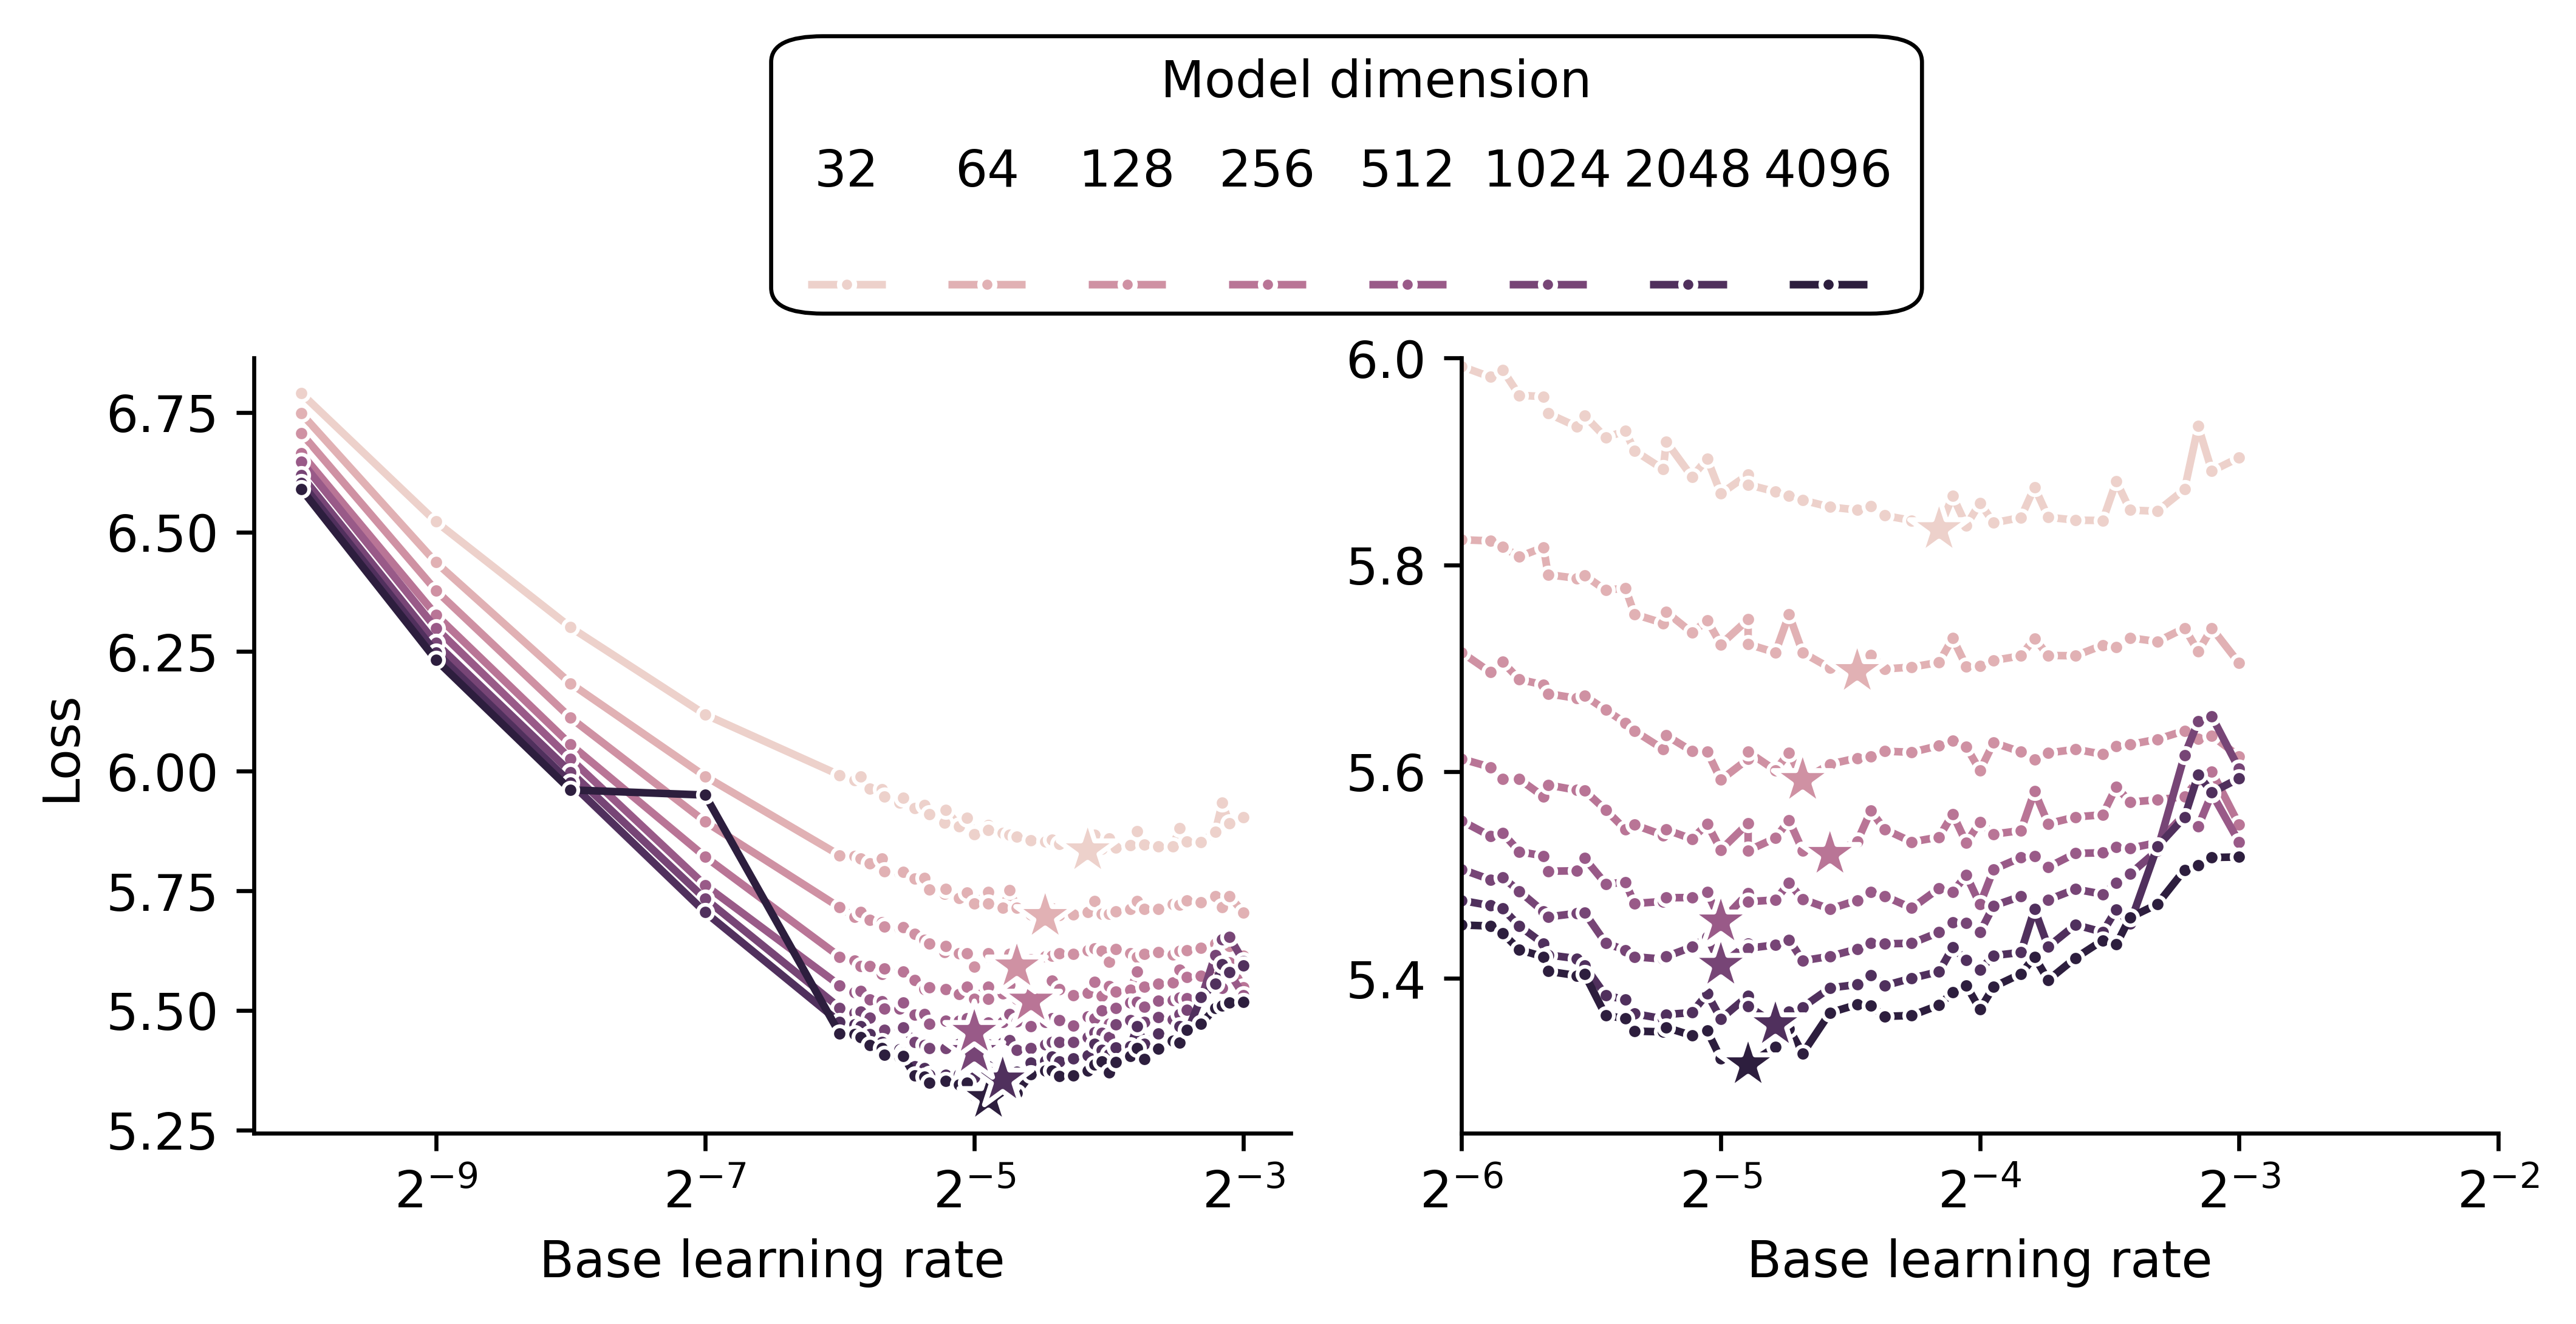

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(2 * 3.54, 3.54), dpi=600)

ax1, ax2 = axs

# final loss
sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax1,
    marker='o',
    markersize=3,
    zorder=1,
    legend='full',
    )

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax1.set_xscale('log', base=2)
# ax.set_xlim(2**-6, 2**-2)
# ax.set_ylim(6.5, 7.5)

sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax2,
    marker='o',
    markersize=3,
    zorder=1,
    legend=False,
    )

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)
ax2.set_xscale('log', base=2)
ax2.set_xlim(2**-6, 2**-2)
ax2.set_ylim(5.25, 6)

ax1.set_ylabel('Loss')
ax1.set_xlabel('Base learning rate')
ax2.set_xlabel('Base learning rate')
ax2.set_ylabel('')

fig.tight_layout(rect=[0, 0, 1, 0.82])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()


# ax.set_title("Loss vs optimal learning rate under muTransfer and full training")

sns.despine()
# plt.tight_layout()
plt.show()

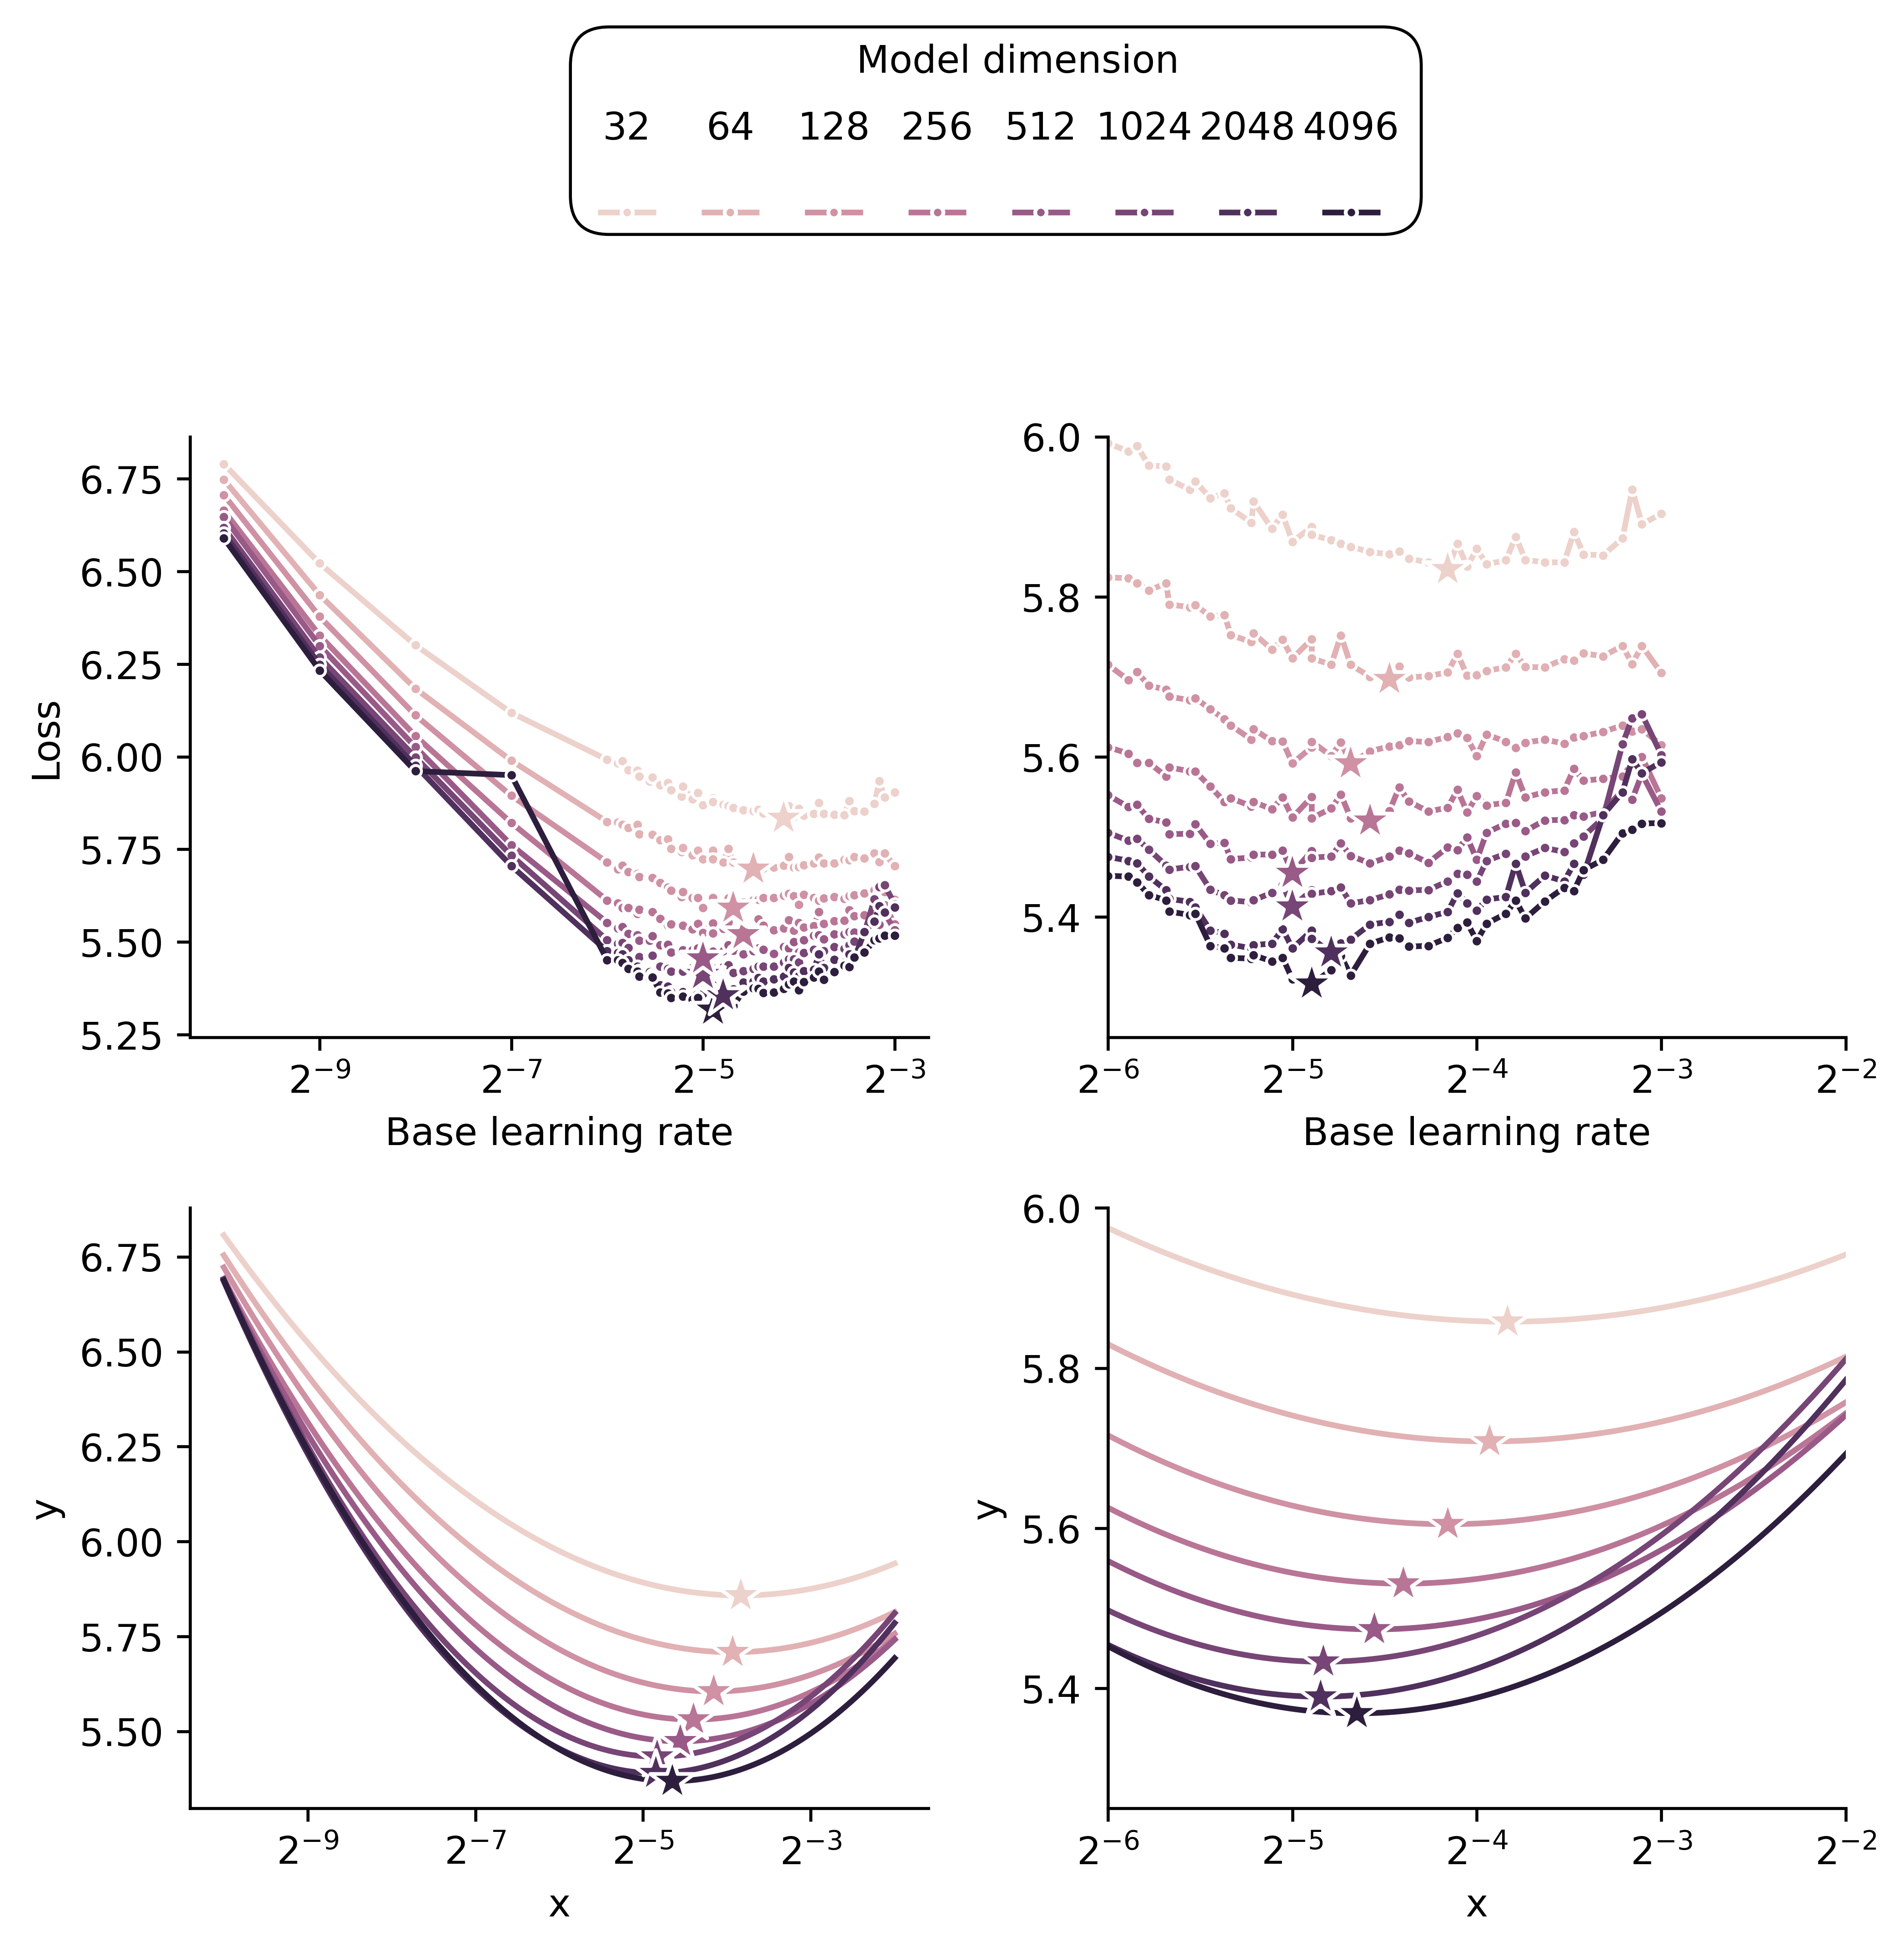

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(2 * 3.54, 2*3.54), dpi=600)

ax1, ax2, ax3, ax4 = axs.flatten()

# final loss
sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax1,
    marker='o',
    markersize=3,
    zorder=1,
    legend='full',
    )

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax1.set_xscale('log', base=2)
# ax.set_xlim(2**-6, 2**-2)
# ax.set_ylim(6.5, 7.5)

sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax2,
    marker='o',
    markersize=3,
    zorder=1,
    legend=False,
    )

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

# =========================================
# final loss
xs = np.logspace(-10, -2, 1000, base=2)
entries = []
minima_entries = []

for d_model in df['d_model'].unique():
    sub = df_best_runs_relative[
        df_best_runs_relative['d_model'] == d_model
    ]
    (a, b, c), fitted_function = fit_quadratic(
        x_data=sub['base_lr'],
        y_data=sub['final_loss'],
    )

    for x in xs:
        entries.append({'x': x, 'y': fitted_function(x), 'd_model': d_model})

    # Vertex of the parabola in log2-space: u* = -b / (2a)
    if a != 0:
        u_star = -b / (2 * a)
        x_star = 2 ** u_star          # convert back to raw base_lr
        y_star = fitted_function(x_star)
    else:
        # degenerate case: fit collapsed to a line, no minimum
        x_star, y_star = np.nan, np.nan

    minima_entries.append({
        'd_model': d_model,
        'base_lr': x_star,
        'final_loss': y_star,
        'a': a, 'b': b, 'c': c,
    })

df_fitted_quadratics = pd.DataFrame(entries)
df_fitted_minima = pd.DataFrame(minima_entries)

sns.lineplot(df_fitted_quadratics,
    x="x",
    y="y",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax3,
    # marker='o',
    # markersize=3,
    zorder=1,
    legend=False,
    )

sns.scatterplot(
    df_fitted_minima,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax3,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax3.set_xscale('log', base=2)

sns.lineplot(df_fitted_quadratics,
    x="x",
    y="y",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax4,
    # marker='o',
    # markersize=3,
    zorder=1,
    legend=False,
    )

sns.scatterplot(
    df_fitted_minima,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax4,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax4.set_xscale('log', base=2)

ax4.set_xlim(2**-6, 2**-2)
ax4.set_ylim(5.25, 6)
# =========================================



ax2.set_xscale('log', base=2)
ax2.set_xlim(2**-6, 2**-2)
ax2.set_ylim(5.25, 6)

ax1.set_ylabel('Loss')
ax1.set_xlabel('Base learning rate')
ax2.set_xlabel('Base learning rate')
ax2.set_ylabel('')

fig.tight_layout(rect=[0, 0, 1, 0.82])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()


# ax.set_title("Loss vs optimal learning rate under muTransfer and full training")

sns.despine()
# plt.tight_layout()
plt.show()

In [36]:
# create column that states whether model was trained to full length or not
df['full_length_training'] = df['n_training_tokens'] == 5.84630272e+09

# split into relative and not relative df
df_relative = df[df['lr_schedule_mode'] == 'relative']
df_not_relative = df[df['lr_schedule_mode'] != "relative"]

# take only data points with more than one rng_seed value per base_lr
group_cols = ["base_lr", "d_model", "full_length_training"]
threshold = 2**-6

def filter_low_seed_count(df, group_cols, threshold):
    seed_counts = df.groupby(group_cols)["rng_seed"].transform("nunique")
    keep = (df["base_lr"] <= threshold) | (seed_counts > 1)
    return df[keep]

df_not_relative = filter_low_seed_count(df_not_relative, group_cols, threshold)
df_relative = filter_low_seed_count(df_relative, group_cols, threshold)


# take best runs for each learning rate (different initialization variances)
df_best_runs_not_relative = (
    df_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training", "rng_seed"], keep="first")
)
df_best_runs_relative = (
    df_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training", "rng_seed"], keep="first")
)

# take optimal lr for optimum plotting
df_optimal_lrs_not_relative = (
    df_best_runs_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training", "rng_seed"], keep="first")
)

# ==============================
df_mean_relative = (
    df_best_runs_relative
    .groupby(['d_model', 'full_length_training', 'base_lr'], as_index=False)['final_loss']
    .mean()
)
df_optimal_lrs_relative = (
    df_mean_relative
    .sort_values('final_loss', ascending=True)
    .drop_duplicates(subset=['d_model', 'full_length_training'], keep='first')
)
# Testing new
# ==============================

# df_optimal_lrs_relative = (
#     df_best_runs_relative
#     .sort_values(by="final_loss", ascending=True)
#     .drop_duplicates(subset=["d_model", "full_length_training", "rng_seed"], keep="first")
# )

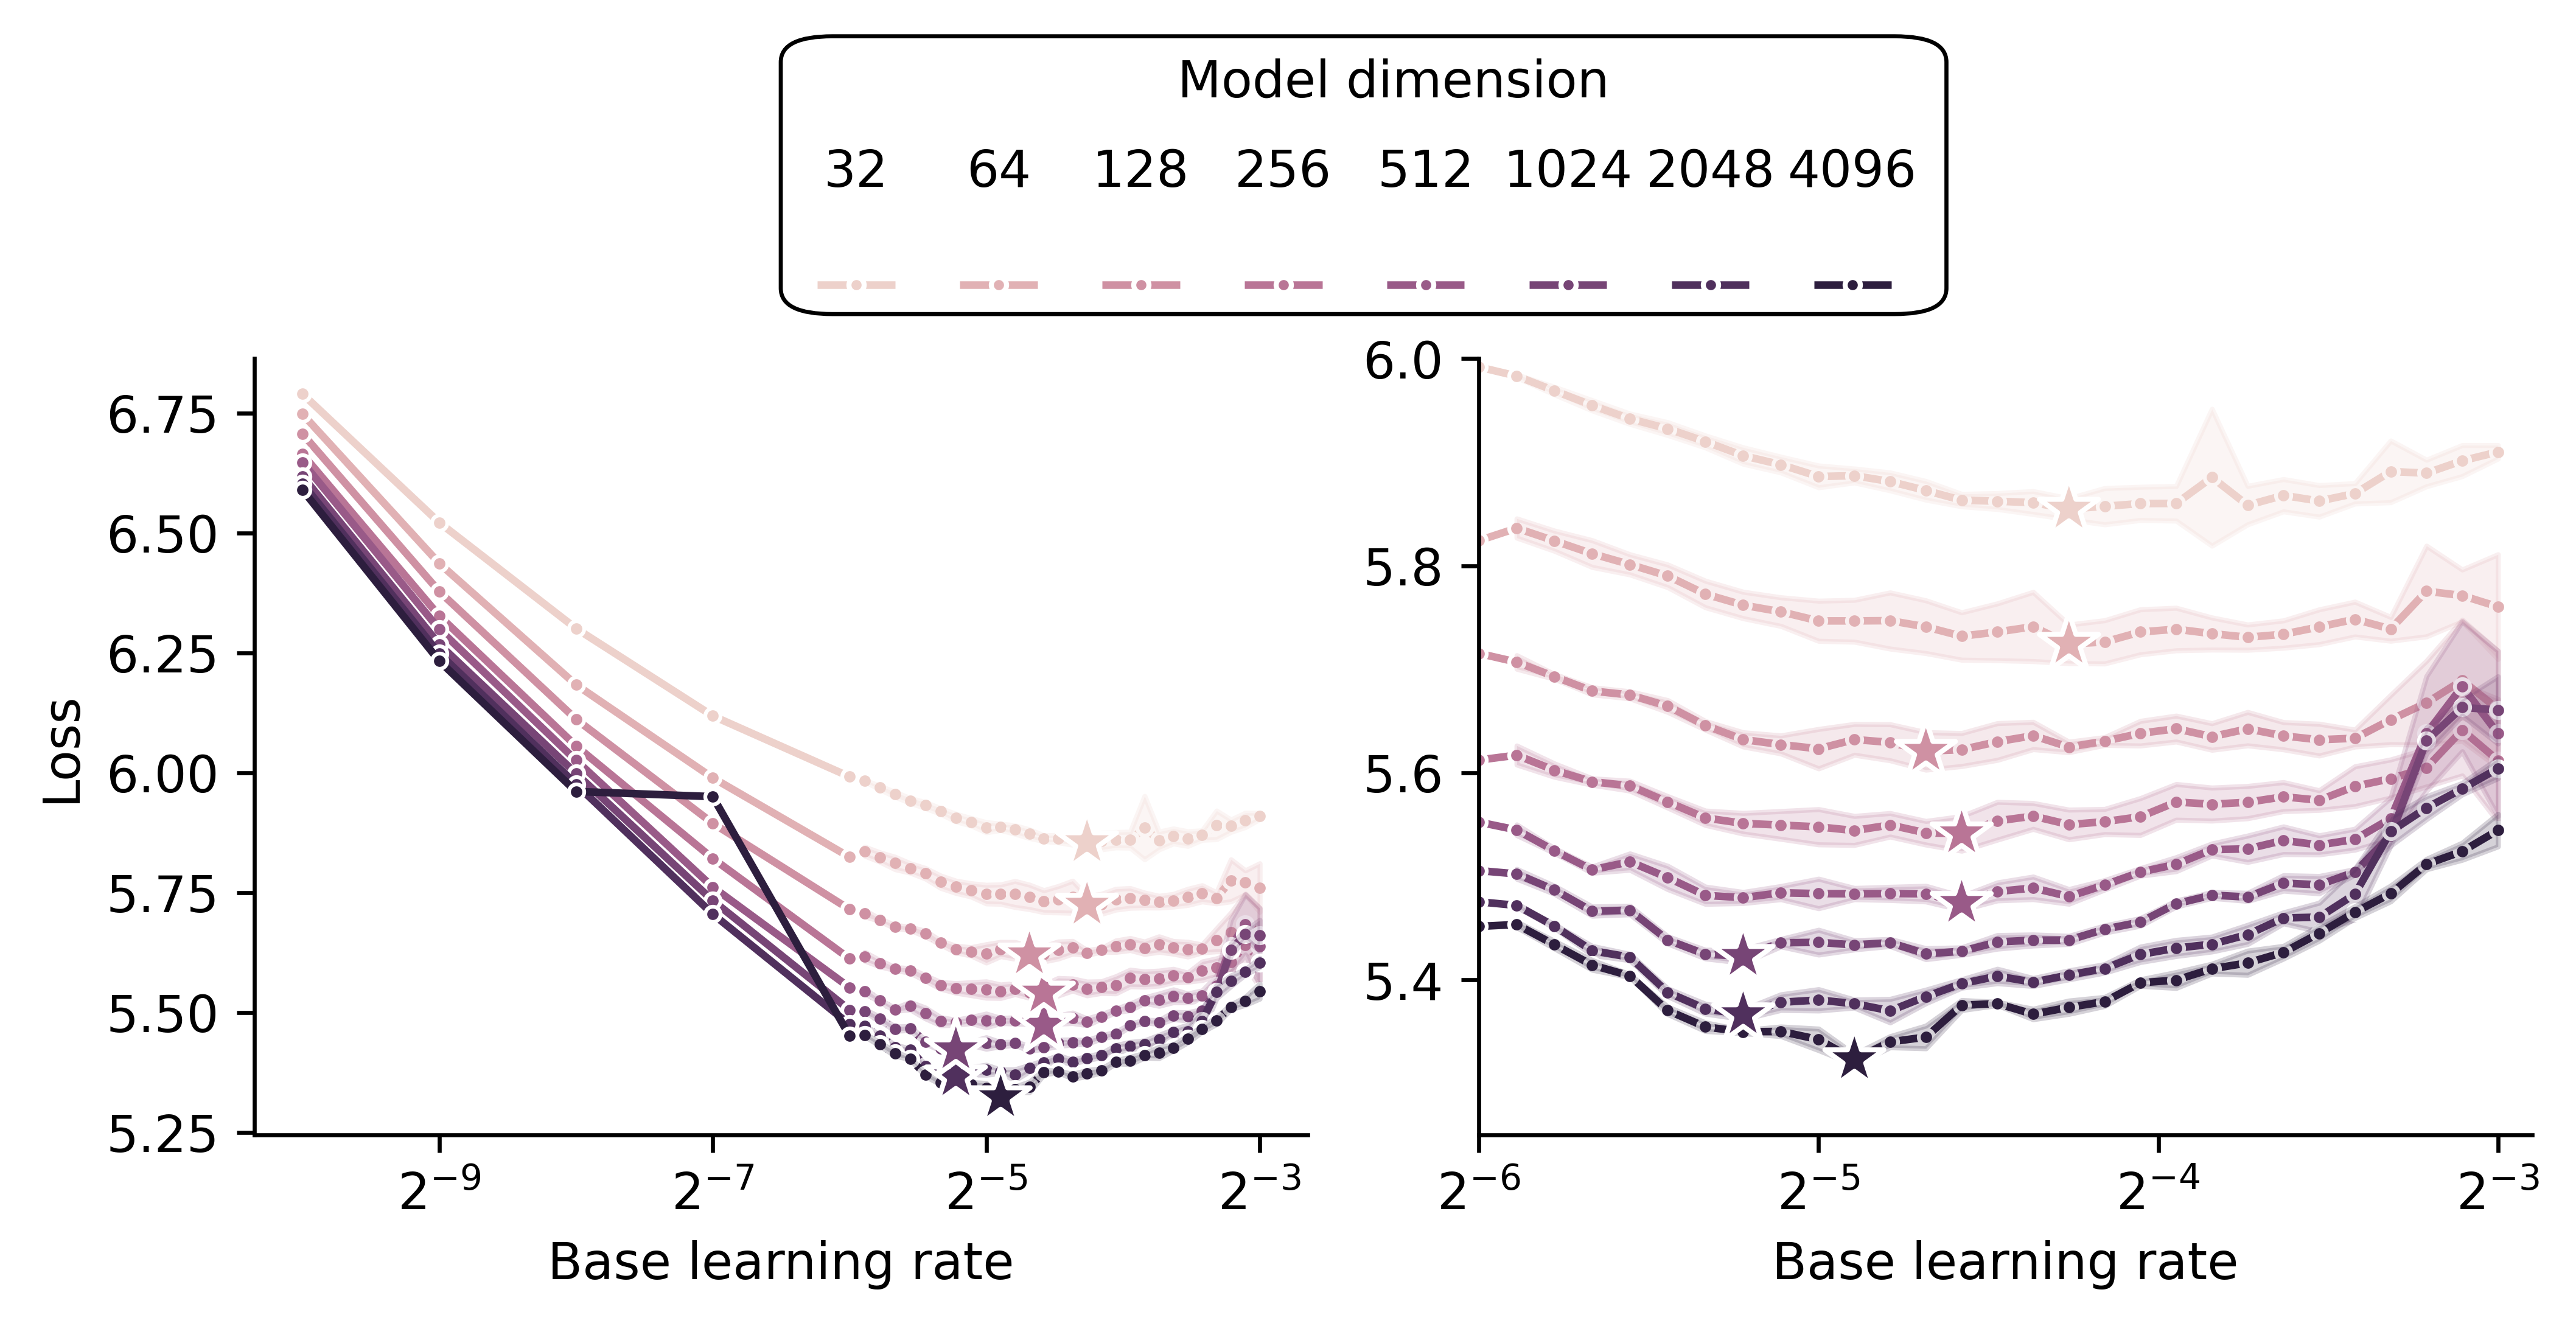

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(2 * 3.54, 3.54), dpi=600)

ax1, ax2 = axs

# final loss
sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax1,
    marker='o',
    markersize=3,
    zorder=1,
    legend='full',
    estimator='mean',        # average over random_seed at each base_lr
    errorbar='sd',           # whisker length = std dev across seeds
)

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax1.set_xscale('log', base=2)
# ax.set_xlim(2**-6, 2**-2)
# ax.set_ylim(6.5, 7.5)

sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax2,
    marker='o',
    markersize=3,
    zorder=1,
    legend=False,
    estimator='mean',        # average over random_seed at each base_lr
    errorbar='sd',           # whisker length = std dev across seeds
)

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)
ax2.set_xscale('log', base=2)
ax2.set_xlim(2**-6, 2**-2.9)
ax2.set_ylim(5.25, 6)

ax1.set_ylabel('Loss')
ax1.set_xlabel('Base learning rate')
ax2.set_xlabel('Base learning rate')
ax2.set_ylabel('')

fig.tight_layout(rect=[0, 0, 1, 0.82])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()


# ax.set_title("Loss vs optimal learning rate under muTransfer and full training")

sns.despine()
# plt.tight_layout()
plt.show()

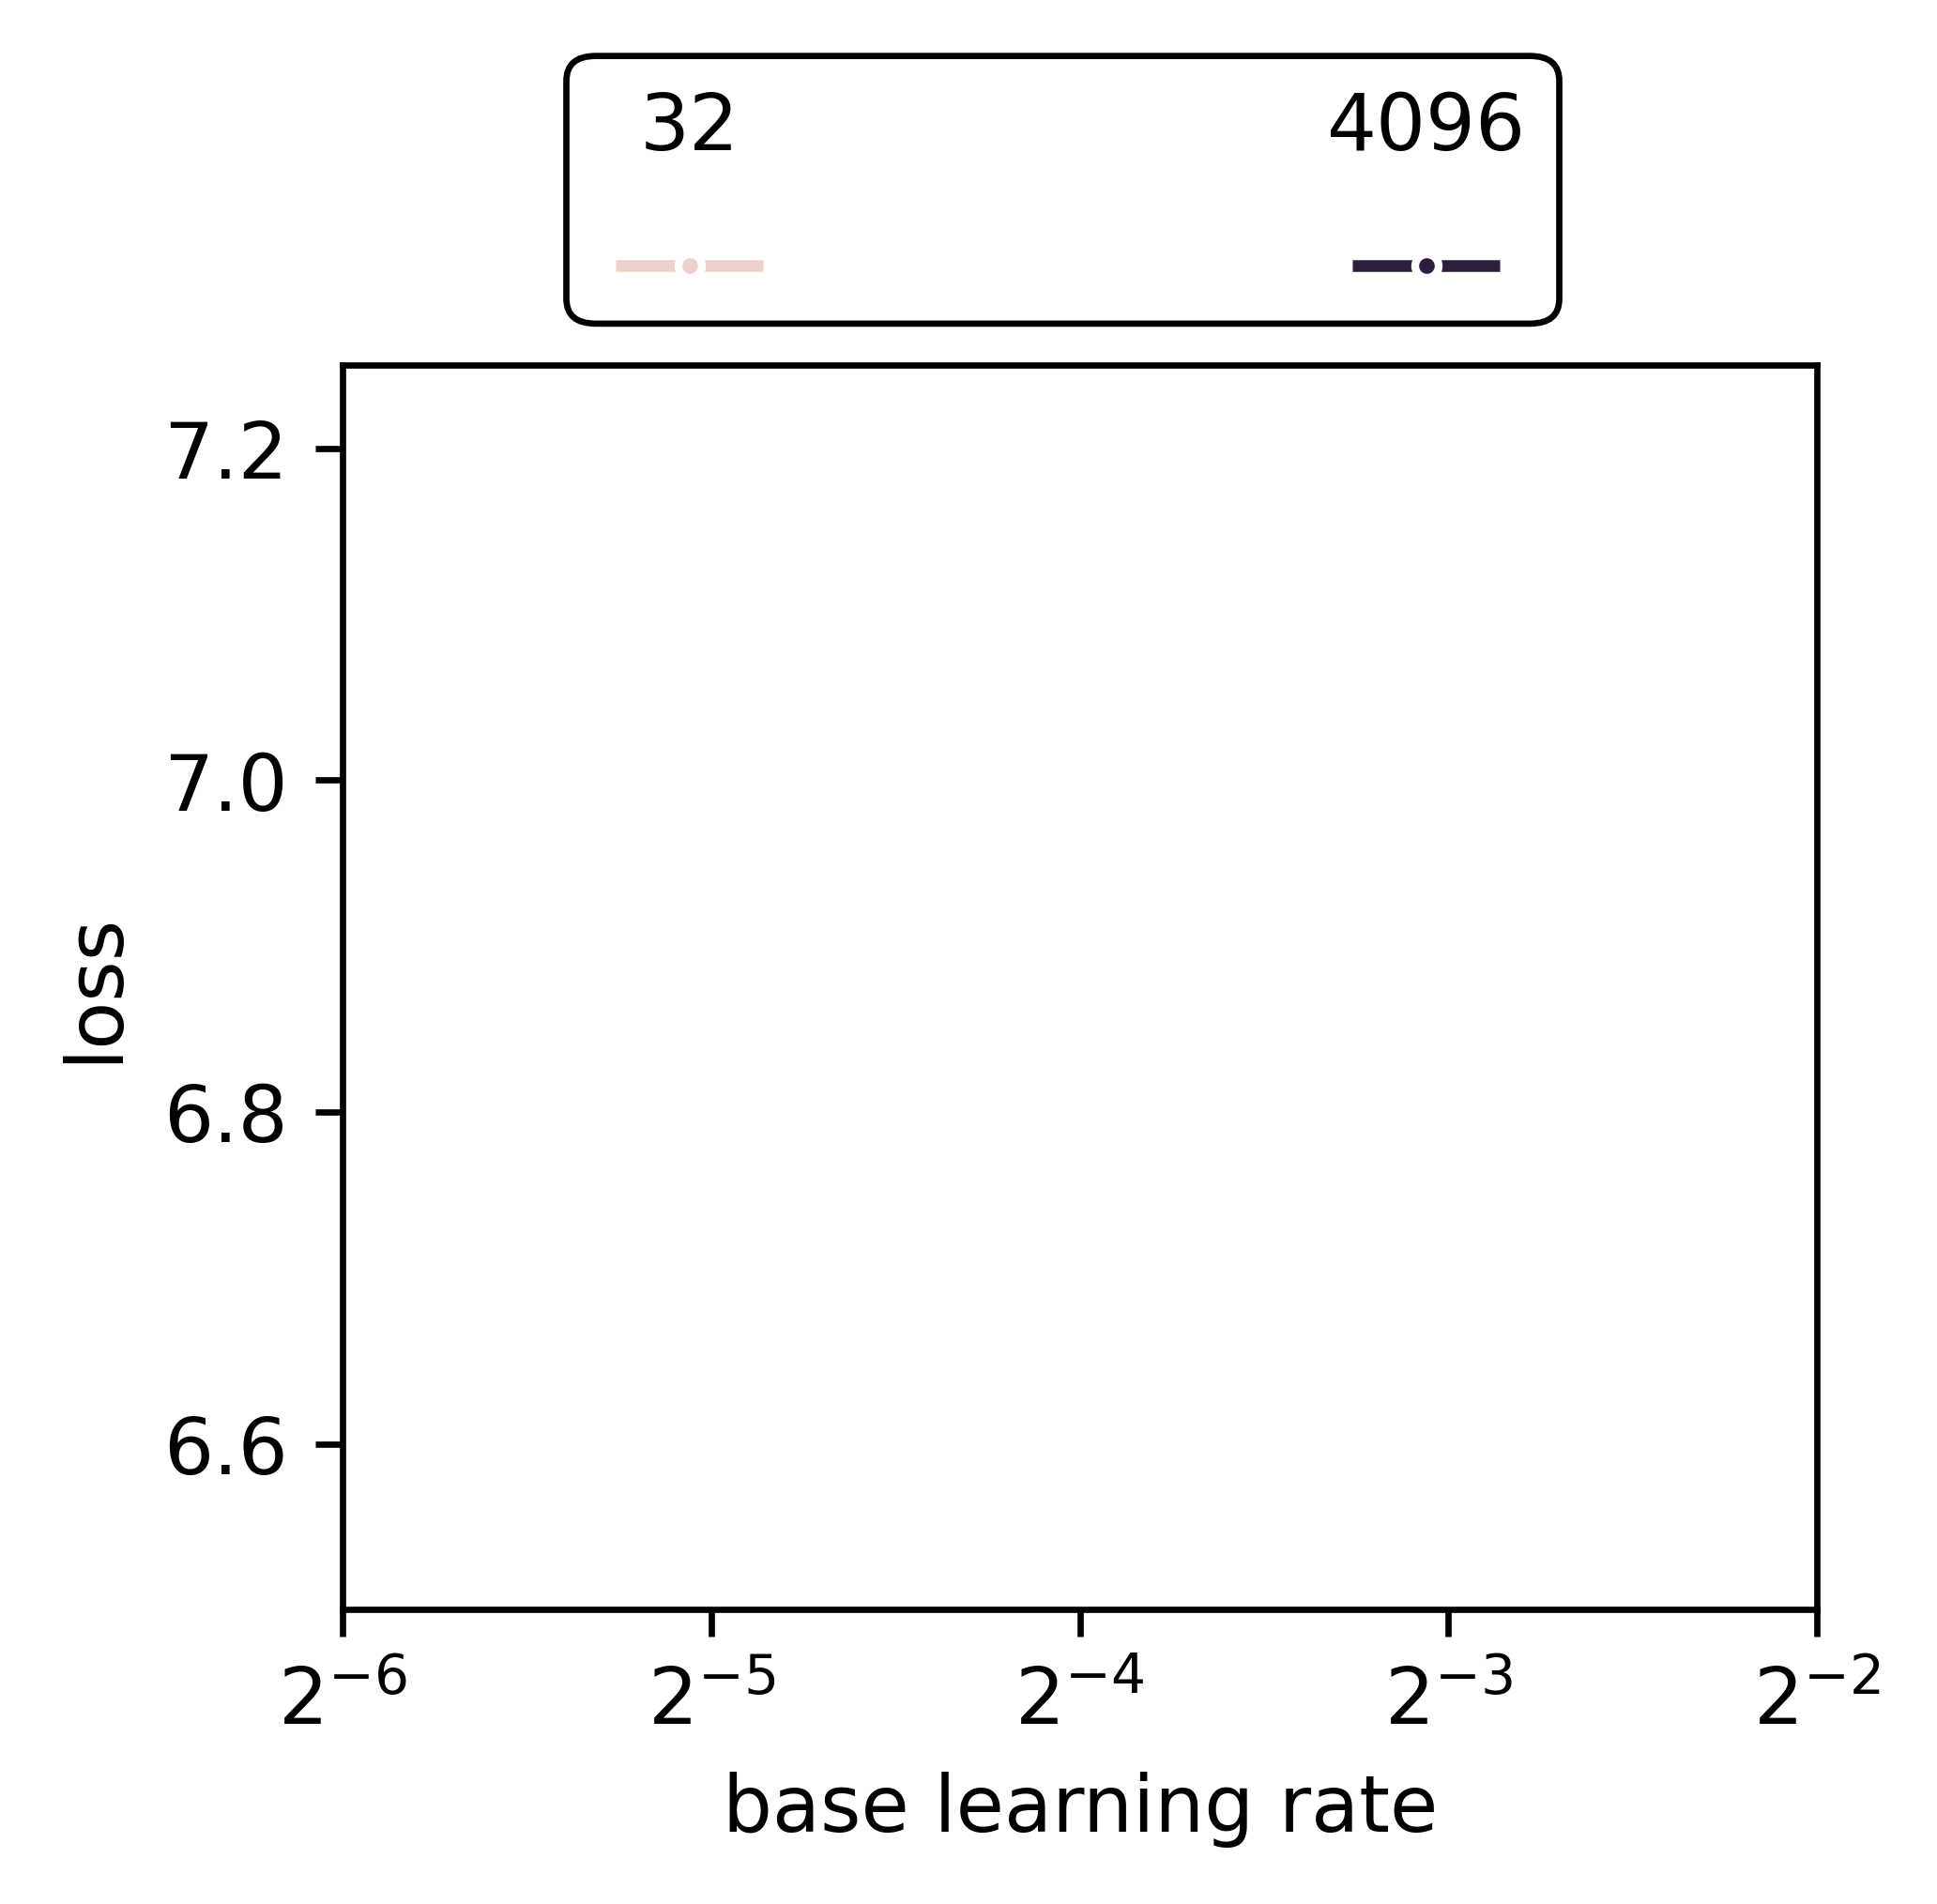

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

# final loss
sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    markersize=3,
    zorder=1,
    legend='full',
    )

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax.set_xscale('log', base=2)
ax.set_xlim(2**-6, 2**-2)
ax.set_ylim(6.5, 7.25)

two_row_legend(ax, x_offset=-0.015)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

ax.set_ylabel('loss')
ax.set_xlabel('base learning rate')
# ax.set_title("Loss vs optimal learning rate under muTransfer and full training")

plt.tight_layout()
plt.show()

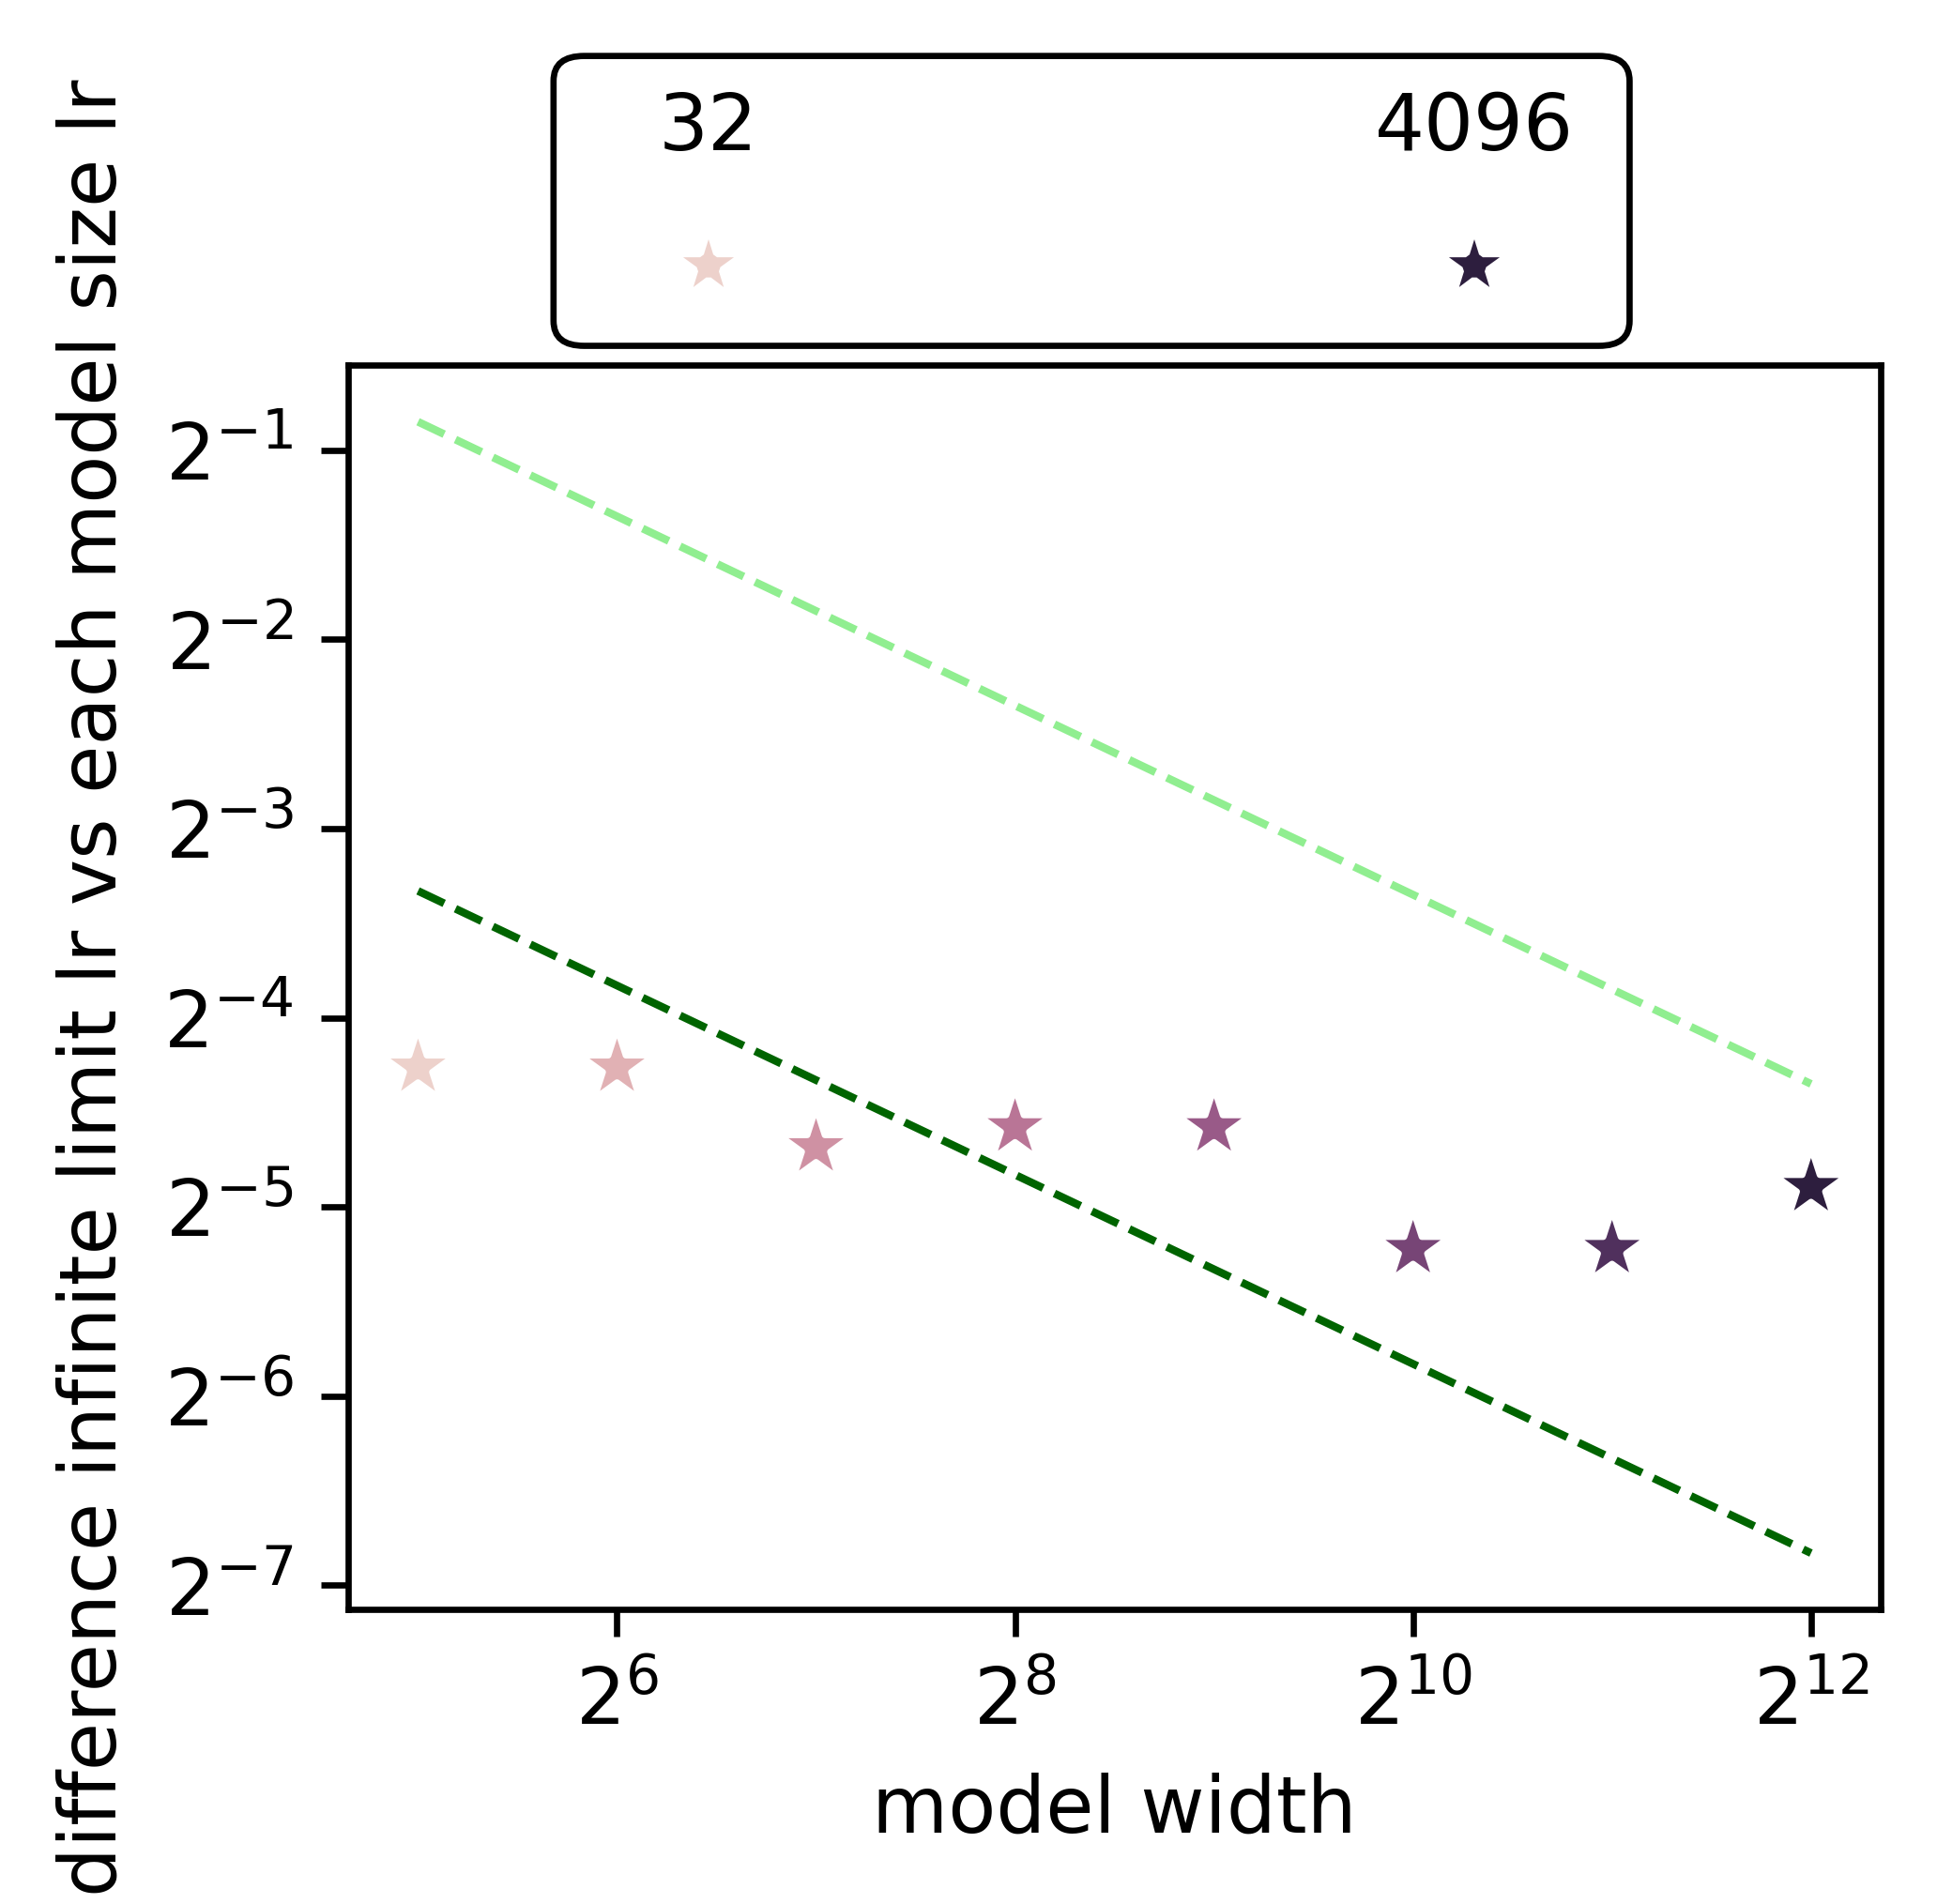

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

infinite_lr = df_optimal_lrs_relative[df_optimal_lrs_relative['d_model'] == 4096]['base_lr'].values
df_optimal_lrs_relative['optimal_lr_distance'] = np.abs(infinite_lr - df_optimal_lrs_relative['base_lr'])

sns.scatterplot(
    df_optimal_lrs_relative,
    x='d_model',
    y='base_lr',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    s=100,
    zorder=2,
    legend='full',
)

xs = np.logspace(5, 12, 8, base=2)
ax.plot(xs, [((2**-0.83 / np.sqrt(i))) for i in xs], linewidth=1, linestyle='--', color='darkgreen')
ax.plot(xs, [((2**1.65 / np.sqrt(i))) for i in xs], linewidth=1, linestyle='--', color='lightgreen')

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
# ax.set_xlim(2**-6, 2**-2)
# ax.set_ylim(6.5, 7.25)

two_row_legend(ax, x_offset=-0.015)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

ax.set_ylabel('difference infinite limit lr vs each model size lr')
ax.set_xlabel('model width')
# ax.set_title("Loss vs optimal learning rate under muTransfer and full training")

plt.tight_layout()
plt.show()

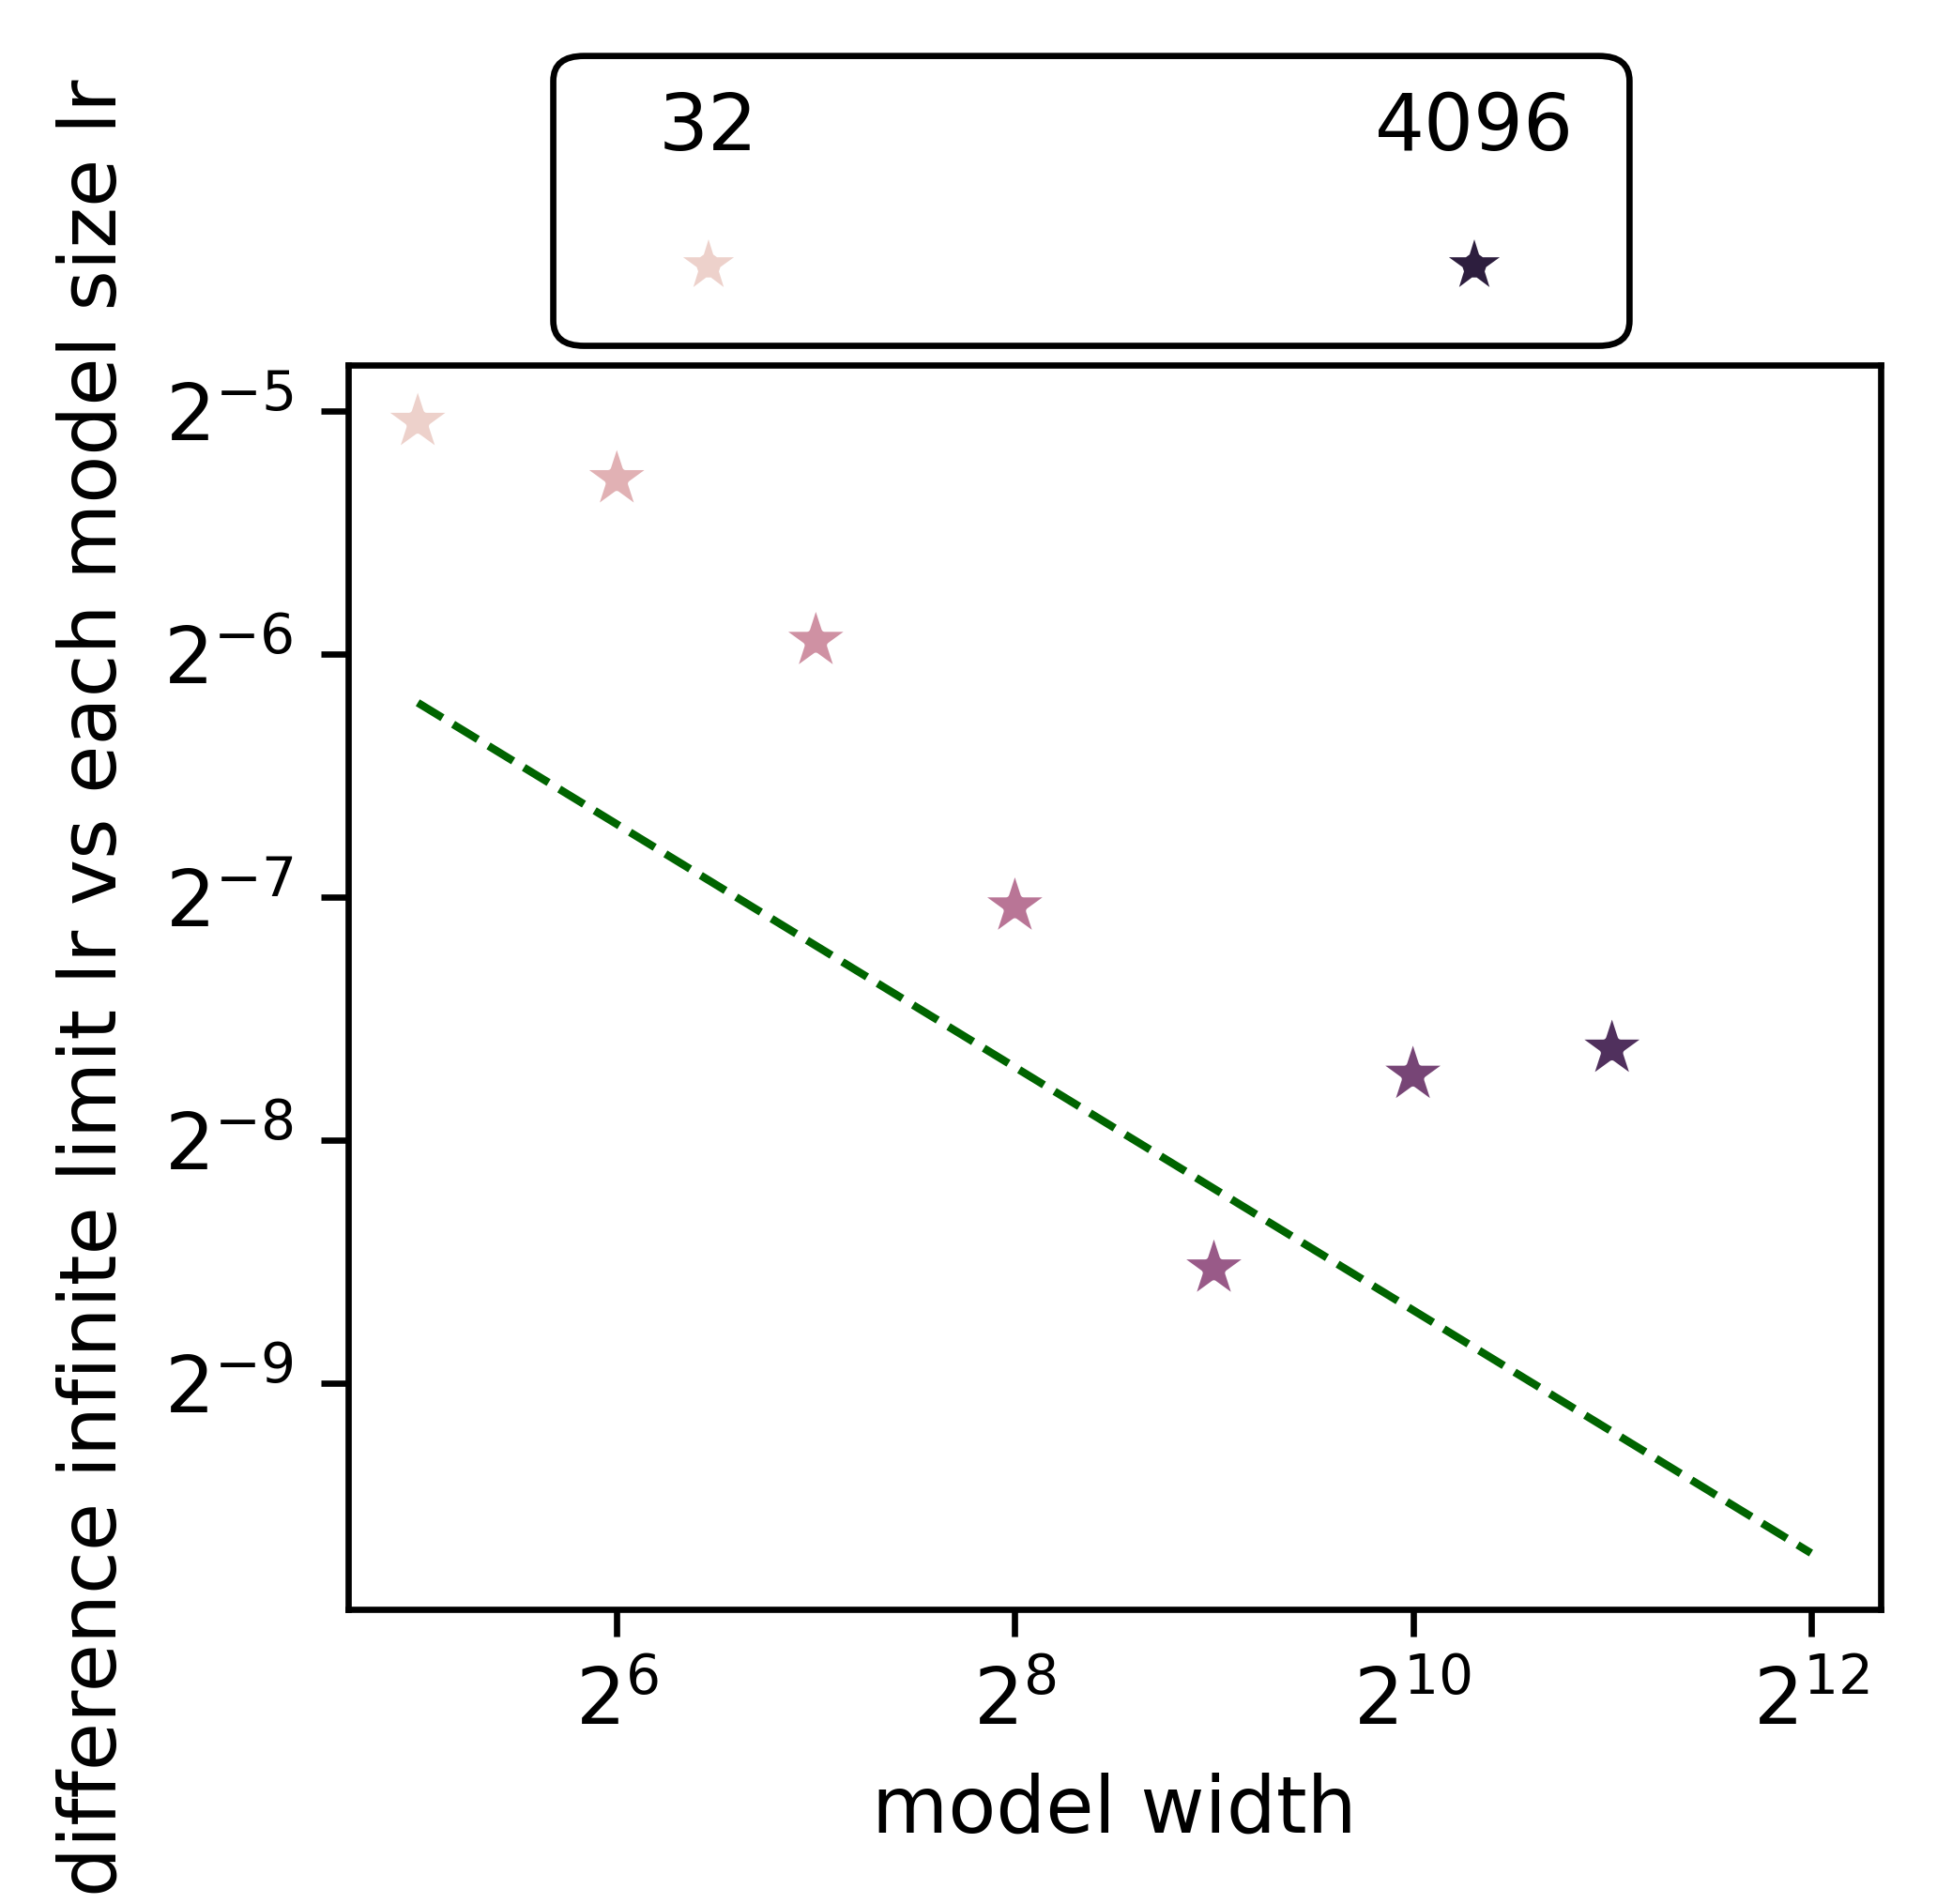

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)


optimum = df_fitted_minima[df_fitted_minima['d_model'] == 4096]['base_lr'].values
df_fitted_minima['distance_optimum'] = np.abs(optimum - df_fitted_minima['base_lr'])

sns.scatterplot(
    df_fitted_minima,
    x='d_model',
    y='distance_optimum',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    s=100,
    zorder=2,
    legend='full',
)

xs = np.logspace(5, 12, 8, base=2)
ax.plot(xs, [((2**-3.7 / np.sqrt(i))) for i in xs], linewidth=1, linestyle='--', color='darkgreen')
# ax.plot(xs, [((2**1.65 / np.sqrt(i))) for i in xs], linewidth=1, linestyle='--', color='lightgreen')

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
# ax.set_xlim(2**-6, 2**-2)
# ax.set_ylim(6.5, 7.25)

two_row_legend(ax, x_offset=-0.015)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

ax.set_ylabel('difference infinite limit lr vs each model size lr')
ax.set_xlabel('model width')
# ax.set_title("Loss vs optimal learning rate under muTransfer and full training")

plt.tight_layout()
plt.show()